# Demo
This notebook shows the model working at a smaller scale - for one random patient in our test data.

In [ ]:
#imports
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt

from sksurv.util import Surv

In [ ]:
#load model :)
model_path = "../models/random_survival_forest.pkl"
rsf = joblib.load(model_path)

In [ ]:
X_test = pd.read_csv("../data/processed/test_features.csv")

# Remove outcome leakage columns
leakage_columns = [
    "death_from_cancer_Living",
    "death_from_cancer_Died of Other Causes"
]

X_test = X_test.drop(
    columns=leakage_columns,
    errors="ignore"
)

print("Test dataset shape:", X_test.shape)

In [ ]:
#pick random patient from test set
import random

patient_index = random.randint(0, len(X_test)-1)

new_patient = X_test.iloc[[patient_index]]

print("Patient feature shape:", new_patient.shape)

In [ ]:
#get their risk score
risk_score = rsf.predict(new_patient)

print(f"Predicted risk score: {risk_score[0]:.4f}")

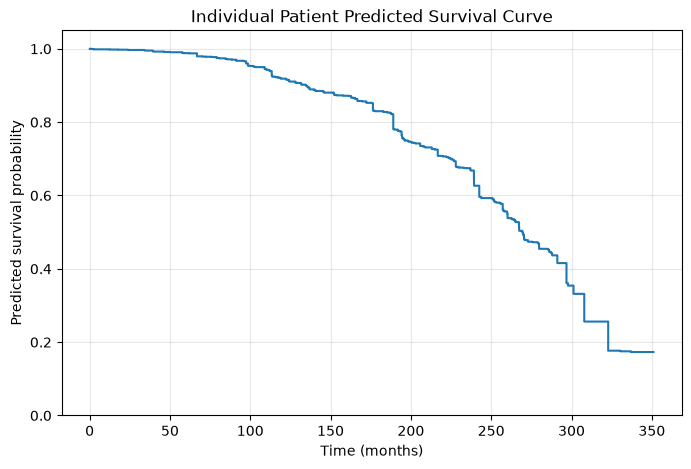

In [ ]:
#show rsf survival curve
survival_function = rsf.predict_survival_function(new_patient)

patient_curve = survival_function[0]

plt.figure(figsize=(8,5))

plt.step(
    patient_curve.x,
    patient_curve.y,
    where="post"
)

plt.xlabel("Time (months)")
plt.ylabel("Predicted survival probability")
plt.title("Individual Patient Predicted Survival Curve")

plt.ylim(0, 1.05)
plt.grid(alpha=0.3)

plt.show()

In [ ]:
#get survival probabilities at specific time points
time_points = [12, 36, 60, 120, 230, 325]

for t in time_points:
    index = np.argmin(abs(patient_curve.x - t))
    
    probability = patient_curve.y[index]
    
    print(f"{t} months survival probability: {probability:.2%}")

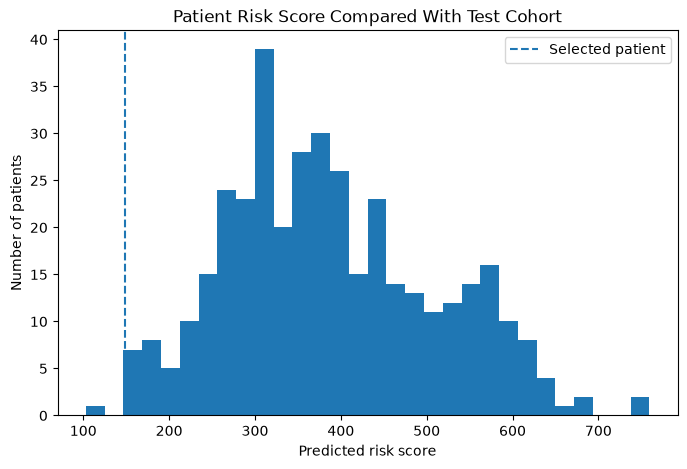

In [ ]:
#compare risk score to distribution of risk scores in test set
all_risks = rsf.predict(X_test)
plt.figure(figsize=(8,5))

plt.hist(
    all_risks,
    bins=30
)

plt.axvline(
    risk_score[0],
    linestyle="--",
    label="Selected patient"
)

plt.xlabel("Predicted risk score")
plt.ylabel("Number of patients")
plt.title("Patient Risk Score Compared With Test Cohort")

plt.legend()

plt.show()